# 12 栈

## 12.1 有效括号

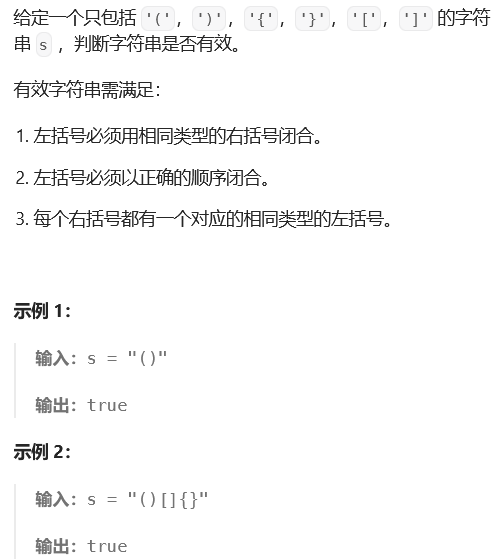

In [ ]:
class Solution:
    def isValid(self, s: str) -> bool:
        # 1. 字典：右括号 → 对应左括号（用来快速查找）
        dic = {')':'(',']':'[','}':'{'}
        
        # 2. 栈：存放左括号
        stack = []
        
        # 3. 遍历字符串里每一个字符
        for char in s:
            
            # 如果当前字符是 右括号（在字典的key里）
            if char in dic:
                # 弹出栈顶元素（如果栈空，就给个空字符串）
                top = stack.pop() if stack else ''
                
                # 弹出来的左括号 必须 == 当前右括号对应的左括号
                if top != dic[char]:
                    return False  # 不匹配 → 直接无效
            
            # 如果是左括号 → 直接入栈
            else:
                stack.append(char)
        
        # 最后栈必须是空的！说明所有左括号都匹配完了
        return not stack


## 12.2 最小栈

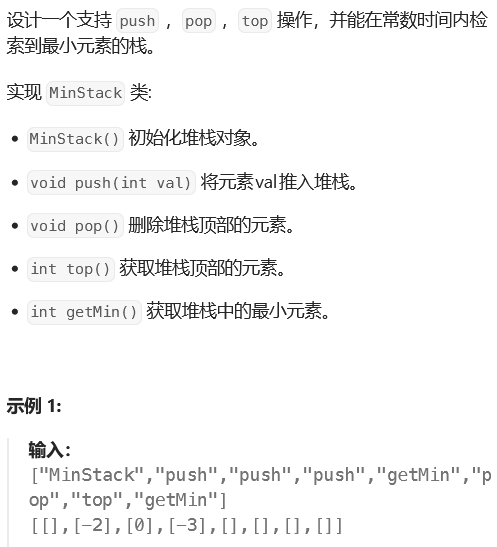

In [ ]:
class MinStack:

    def __init__(self):
        # 主栈 + 最小栈
        self.stack = []
        self.min_stack = []

    def push(self, val: int) -> None:
        self.stack.append(val)
        # 小于等于才入最小栈，保证重复最小值也能同步弹出
        if not self.min_stack or val <= self.min_stack[-1]:
            self.min_stack.append(val)

    def pop(self) -> None:
        if not self.stack:
            return
        top_val = self.stack.pop()
        # 弹出的是当前最小值，最小栈也要弹
        if top_val == self.min_stack[-1]:
            self.min_stack.pop()

    def top(self) -> int:
        return self.stack[-1]

    def getMin(self) -> int:
        return self.min_stack[-1]

## 12.3 字符串解码

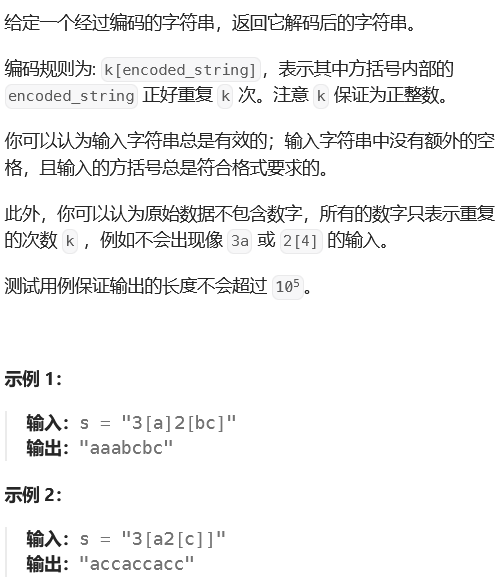

In [ ]:
class Solution:
    def decodeString(self, s: str) -> str:
        num_stack = []
        str_stack = []
        res = ""
        num = 0
        
        for c in s:
            if c.isdigit():
                num = num * 10 + int(c)
            elif c == '[':
                num_stack.append(num)
                str_stack.append(res)
                num = 0
                res = ""
            elif c == ']':
                k = num_stack.pop()
                pre_str = str_stack.pop()
                res = pre_str + res * k
            else:
                res += c
        return res

## 12.4 每日温度

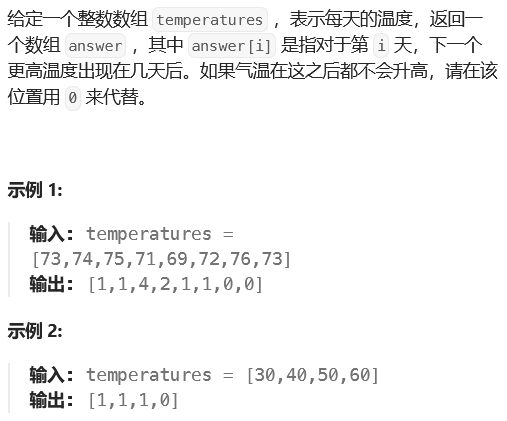

In [ ]:
class Solution:
    def dailyTemperatures(self, temperatures: List[int]) -> List[int]:
        n = len(temperatures)
        res = [0] * n
        stack = []
        
        for i in range(n):
            # 单调栈：当前温度比栈顶大，更新答案
            while stack and temperatures[i] > temperatures[stack[-1]]:
                idx = stack.pop()
                res[idx] = i - idx
            stack.append(i)
        return res